# SINC3 frequency responce

In [140]:
# ==== 參數設定 ====

# 圖一
R = 256
# 圖二
signal_frequency = 128 * pow (10, 3)          # 訊號頻率
sampling_frequency = 2048 * pow(10, 3)      # 取樣頻率
num_periods = 4                             # 取樣幾個週期
noise_std = 0.3                             # 高斯雜訊標準差
# 圖三
target_ratio = 256                          # f_sampling / f_signal      
R_int  = [32, 64, 128, 256]                 # 感興趣的R值

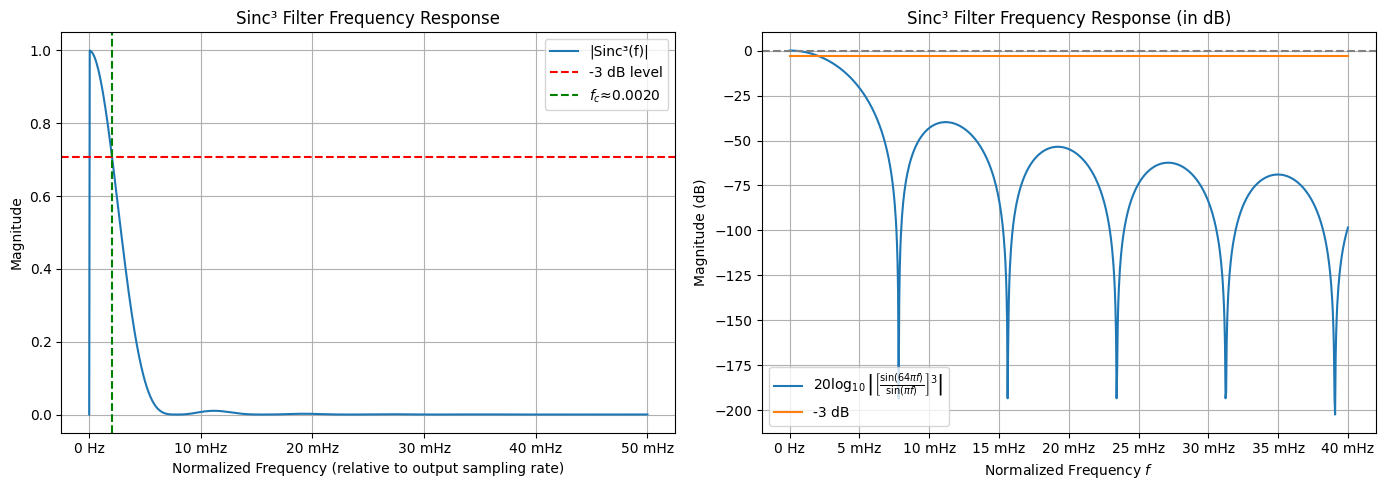

In [134]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.ticker import EngFormatter

epsilon = 1e-12
frequency_formatter = EngFormatter(unit='Hz')

# ----------- Sinc^3 函數（Linear Magnitude）------------
def sinc3_response(f):
    numerator = np.sin(np.pi * f * R)
    denominator = np.sin(np.pi * f) + epsilon
    magnitude_responce = np.abs(numerator / denominator) ** 3
    return magnitude_responce / (R ** 3)

def target_func(f):
    return sinc3_response(f) - 1 / np.sqrt(2)

initial_guess = 1 / (2 * R)
fc_solution = fsolve(target_func, initial_guess)[0]

frequencies_linear = np.linspace(0, 0.05, 1000)
response_linear = sinc3_response(frequencies_linear)

# ----------- Sinc^3 函數（dB）------------
f = np.linspace(0, 0.04, 1000)
pi_f = np.pi * f
pi_f[pi_f == 0] = epsilon
H = (np.sin(R * pi_f) / np.sin(pi_f)) ** 3
H = np.abs(H)
H[H == 0] = epsilon
H_dB = 20 * (np.log10(H) - np.log10(R ** 3))
S = [-3 for _ in range(len(f))]

# ----------- 畫圖：左右排列 ------------
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# 左圖：Linear Magnitude
ax1 = axs[0]
ax1.xaxis.set_major_formatter(frequency_formatter)
ax1.plot(frequencies_linear, response_linear, label='|Sinc³(f)|')
ax1.axhline(1 / np.sqrt(2), color='red', linestyle='--', label='-3 dB level')
ax1.axvline(fc_solution, color='green', linestyle='--', label=f'$f_c ≈ {fc_solution:.4f}$')
ax1.set_title("Sinc³ Filter Frequency Response")
ax1.set_xlabel("Normalized Frequency (relative to output sampling rate)")
ax1.set_ylabel("Magnitude")
ax1.grid(True)
ax1.legend()

# 右圖：dB Magnitude
ax2 = axs[1]
ax2.xaxis.set_major_formatter(frequency_formatter)
ax2.plot(f, H_dB, label=r'$20\log_{10} \left| \left[\frac{\sin(64\pi f)}{\sin(\pi f)} \right]^3 \right|$')
ax2.plot(f, S, label='-3 dB')
ax2.set_title("Sinc³ Filter Frequency Response (in dB)")
ax2.set_xlabel("Normalized Frequency $f$")
ax2.set_ylabel("Magnitude (dB)")
ax2.grid(True, which='both')
ax2.axhline(0, color='gray', linestyle='--')
ax2.legend()

plt.tight_layout()
plt.show()


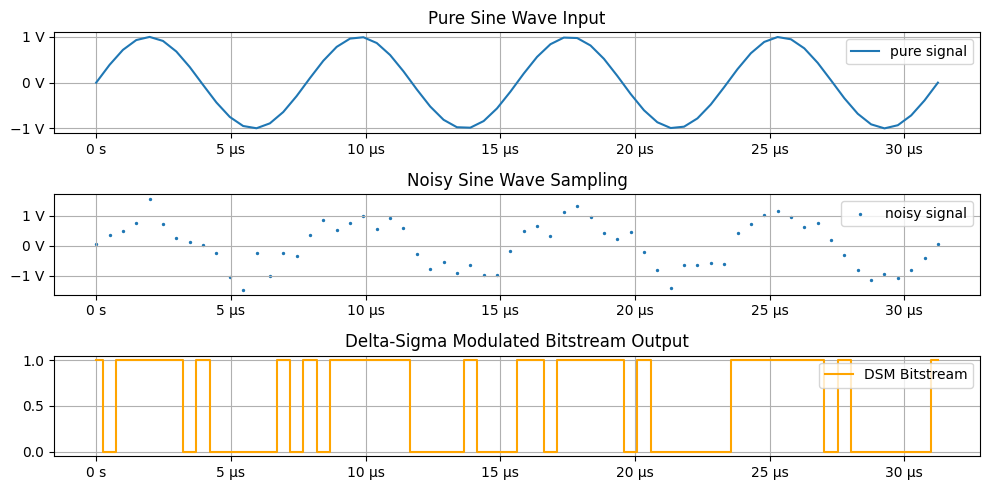

In [141]:
total_points = int(sampling_frequency / signal_frequency * num_periods) # 總取樣點數
# ==== 時間軸 ====
t = np.linspace(0, 1 / sampling_frequency * total_points, total_points)

# ==== 輸入訊號 ====
omega = 2 * np.pi * signal_frequency
pure_signal = 1 * np.sin(omega * t)
noisy_signal = pure_signal + np.random.normal(loc=0.0, scale=noise_std, size=total_points)

# ==== 第一階 Delta-Sigma Modulator ====
integrator = 0
feedback = 0
bitstream = []

for x in noisy_signal:  
    integrator += x - feedback
    if integrator >= 0:
        bit = 1
        feedback = 1
    else:
        bit = 0
        feedback = -1
    bitstream.append(bit)

# ==== 輸出 bitstream 到 TXT 檔案 ====
with open("c:/iDesign/isinc3/delta_sigma_output.txt", "w") as f:
    time_interval = round(1 / sampling_frequency * pow(10, 9) / 2)
    time_stop = time_interval * total_points * 2
    f.write(f"{total_points}\n{time_interval}\n{time_stop}\n")
    for bit in bitstream:
        f.write(f"{bit}\n")

t_bitstream = t[:len(bitstream)]  

# ==== 畫圖 ====
time_formatter = EngFormatter(unit='s')     
volt_formatter = EngFormatter(unit='V')   

plt.figure(figsize=(10, 5))

# 第一張圖：純淨訊號
ax1 = plt.subplot(3, 1, 1)
ax1.plot(t, pure_signal, label='pure signal')
ax1.set_title("Pure Sine Wave Input")
ax1.grid(True)
ax1.legend(loc='upper right')
ax1.xaxis.set_major_formatter(time_formatter)
ax1.yaxis.set_major_formatter(volt_formatter)

# 第二張圖：加入雜訊的訊號
ax2 = plt.subplot(3, 1, 2)
ax2.scatter(t, noisy_signal, s=2, label='noisy signal')
ax2.set_title('Noisy Sine Wave Sampling')
ax2.grid(True)
ax2.legend(loc='upper right')
ax2.xaxis.set_major_formatter(time_formatter)
ax2.yaxis.set_major_formatter(volt_formatter)

# 第三張圖：Delta-Sigma bitstream
ax3 = plt.subplot(3, 1, 3)
ax3.step(t_bitstream, bitstream, where='mid', label="DSM Bitstream", color='orange')
ax3.set_title("Delta-Sigma Modulated Bitstream Output")
ax3.grid(True)
ax3.legend(loc='upper right')
ax3.xaxis.set_major_formatter(time_formatter)

plt.tight_layout()

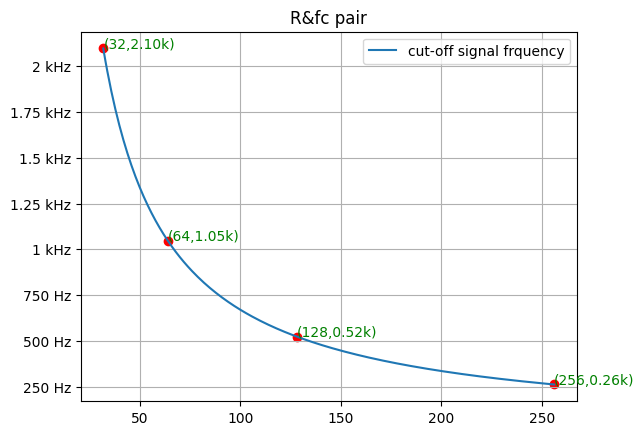

In [132]:
fs_max = []
fs_int = []
for x in Rpoints:
    R = x
    initial_guess = 1 / ( 2 * R)
    solu = target_ratio * fsolve(target_func, initial_guess)[0] * pow(10,3)
    fs_max.append(solu)
    if( x in R_int):
        fs_int.append(solu)

ax = plt.subplot()
ax.plot(Rpoints, fs_max, label="cut-off signal frquency")
ax.yaxis.set_major_formatter(frequency_formatter)
ax.scatter(R_int, fs_int, color='red')
ax.set_title("R&fc pair")
ax.grid(True)
ax.legend(loc = 'upper right')
for i in range(len(R_int)):
    ax.text(R_int[i], fs_int[i], f'({R_int[i]:d},{fs_int[i]/1000:.2f}k)', color='green')